##### Importing packages and libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
import math

In [3]:
sys.path.append(os.path.abspath("../.."))   # Uncomment and run it once (For importing package)
sys.path
from src import utils

##### Settings for Pandas and vizualization

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
sns.set_style('whitegrid')
sns.set_palette('viridis')

##### Loading the dataset

In [5]:
df = pd.read_csv("../../data/raw/cc_calls.csv")
display(df.head())

,Contact_ID,Call_Date,Direction,cc_care_package,cc_care_package_discussed,cc_urgency_getting_on_site,cc_external_consultant,cc_agent_cross_sell_attempt,cc_customer_issues_concerns,cc_business_struggles_financial_hardship,cc_call_initiated_by,cc_questionnaire_completion,cc_chasing_response,cc_issues_within_questionnaire,cc_login_issues,cc_platform_issues,cc_dissatisfaction_time_to_complete,cc_process_complexity_concerns,cc_questions_harder_than_expected,cc_dissatisfaction_support,cc_contractor_sentiment,cc_contractor_sentiment_start_score,cc_contractor_sentiment_end_score,cc_contractor_sentiment_overall_score,cc_contractor_sentiment_issues_score,cc_pricing_mentioned,cc_pricing_sentiment_impact,cc_refund_discussed,cc_contractor_suggest_leave,cc_contractor_complained,Co_Ref,Analysed_Call,Call_Year
0,6.255130e+11,08-05-2025,OUT_BOUND,Standard,Yes,No,No,No,Yes,Yes,Customer,No,No,No,No,Yes,Yes,Yes,No,Yes,Dissatisfied,20,30,30,20,Yes,Yes,No,Yes,Yes,HV3323,1,2025
1,5.910870e+11,25-11-2024,OUT_BOUND,Standard,Yes,No,No,No,Yes,No,Agent,Yes,No,No,No,Yes,Yes,Yes,No,No,Dissatisfied,0,0,0,0,Yes,Yes,No,Yes,Yes,PJ7066,1,2024
2,5.650910e+11,23-10-2024,IN_BOUND,Standard,Yes,No,No,No,Yes,No,Customer,No,No,No,No,Yes,No,Yes,No,No,Dissatisfied,20,60,40,20,Yes,Yes,No,Yes,Yes,DP6030,1,2024
3,5.939750e+11,13-01-2025,IN_BOUND,Premier,Yes,No,No,No,Yes,Yes,Customer,Yes,No,No,No,Yes,Yes,Yes,No,Yes,Dissatisfied,20,60,40,30,Yes,Yes,Yes,Yes,Yes,AM2413,1,2025
4,6.222820e+11,19-03-2025,IN_BOUND,Standard,Yes,No,No,No,Yes,Yes,Customer,No,No,NaN,No,No,No,Yes,No,Yes,Dissatisfied,20,40,40,20,Yes,Yes,No,Yes,Yes,ED6707,1,2025


Converting column_names to snake_case

In [6]:
df = utils.convert_columns_to_snake_case(df)

##### Understanding the dataset

In [7]:
print("Shape:", df.shape)

print("\nInfo:")
df.info()

Shape: (32882, 33)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32882 entries, 0 to 32881
Data columns (total 33 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   contact_id                                32882 non-null  float64
 1   call_date                                 32882 non-null  object 
 2   direction                                 32882 non-null  object 
 3   cc_care_package                           32744 non-null  object 
 4   cc_care_package_discussed                 32744 non-null  object 
 5   cc_urgency_getting_on_site                32744 non-null  object 
 6   cc_external_consultant                    32744 non-null  object 
 7   cc_agent_cross_sell_attempt               32744 non-null  object 
 8   cc_customer_issues_concerns               32744 non-null  object 
 9   cc_business_struggles_financial_hardship  32744 non-null  object 
 10  cc_call_

Missing Values Analysis

In [8]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().mean() * 100).round(2)
}).sort_values('Missing %', ascending=False)
missing

,Missing Count,Missing %
co_ref,1196,3.64
cc_issues_within_questionnaire,466,1.42
cc_care_package,138,0.42
cc_care_package_discussed,138,0.42
cc_urgency_getting_on_site,138,0.42
cc_external_consultant,138,0.42
cc_agent_cross_sell_attempt,138,0.42
cc_customer_issues_concerns,138,0.42
cc_business_struggles_financial_hardship,138,0.42
cc_call_initiated_by,138,0.42


In [9]:
df.nunique()

contact_id                                    496
call_date                                     323
direction                                       2
cc_care_package                                57
cc_care_package_discussed                       3
cc_urgency_getting_on_site                      3
cc_external_consultant                          3
cc_agent_cross_sell_attempt                    23
cc_customer_issues_concerns                     9
cc_business_struggles_financial_hardship        6
cc_call_initiated_by                            6
cc_questionnaire_completion                     3
cc_chasing_response                           179
cc_issues_within_questionnaire                 59
cc_login_issues                                12
cc_platform_issues                              4
cc_dissatisfaction_time_to_complete             3
cc_process_complexity_concerns                 25
cc_questions_harder_than_expected               7
cc_dissatisfaction_support                      4


##### Dropping redundant columns and duplicated rows

Checking if duplicated rows exist

In [10]:
print("Duplicate rows exists: ", df.duplicated().any())
print("Duplicate rows: ", df.duplicated().sum())

Duplicate rows exists:  True
Duplicate rows:  93


Dropping duplicated rows

In [11]:
df = df.drop_duplicates()

Dropping rows where co_ref is null

In [12]:
# As if co_ref is null we cannot join with other dataset
df = df.dropna(subset=['co_ref'])
df.shape

(31636, 33)

Dropping analyzed call as it contains only 1's

In [13]:
# No variance in analyzed_call column 
df = df.drop(columns=['analysed_call'])

Dropping call_year column as call_year can be extracted from call_date

In [14]:
df = df.drop(columns=['call_year'])
df.shape

(31636, 31)

##### Transforming columns

Converting date columns to common datetime format

In [15]:
# Converts call_date to common yyyy-mm-dd format
df['call_date'] = pd.to_datetime(df['call_date'], dayfirst=True, errors='coerce')

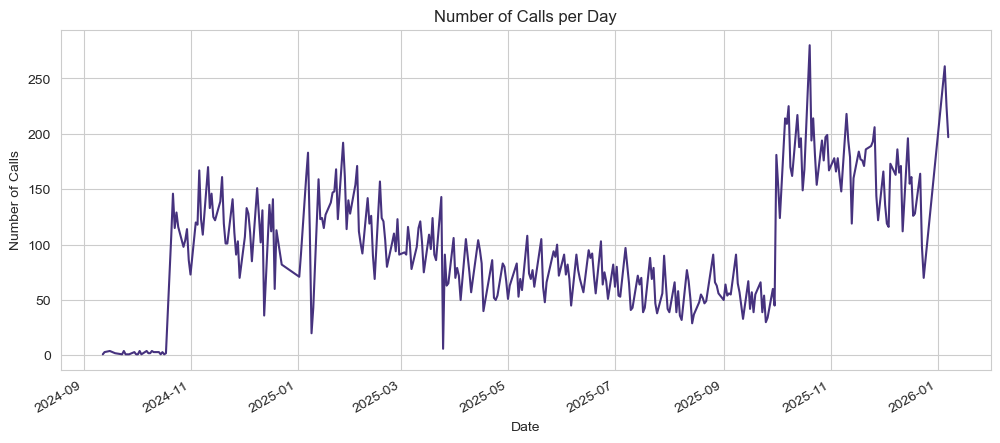

In [16]:
calls_per_day = df['call_date'].value_counts().sort_index()

calls_per_day.plot(figsize=(12,5))
plt.title("Number of Calls per Day")
plt.xlabel("Date")
plt.ylabel("Number of Calls")
plt.show()

Identifying categorical and numerical features

In [17]:
numerical_df = df.select_dtypes(include=['number'])
categorical_df = df.select_dtypes(include=['object', 'category'])

num_cols = numerical_df.columns.tolist()
cat_cols = categorical_df.columns.tolist()

print(f"Numerical: {num_cols}")
print(f"Categorical: {cat_cols}")

Numerical: ['contact_id']
Categorical: ['direction', 'cc_care_package', 'cc_care_package_discussed', 'cc_urgency_getting_on_site', 'cc_external_consultant', 'cc_agent_cross_sell_attempt', 'cc_customer_issues_concerns', 'cc_business_struggles_financial_hardship', 'cc_call_initiated_by', 'cc_questionnaire_completion', 'cc_chasing_response', 'cc_issues_within_questionnaire', 'cc_login_issues', 'cc_platform_issues', 'cc_dissatisfaction_time_to_complete', 'cc_process_complexity_concerns', 'cc_questions_harder_than_expected', 'cc_dissatisfaction_support', 'cc_contractor_sentiment', 'cc_contractor_sentiment_start_score', 'cc_contractor_sentiment_end_score', 'cc_contractor_sentiment_overall_score', 'cc_contractor_sentiment_issues_score', 'cc_pricing_mentioned', 'cc_pricing_sentiment_impact', 'cc_refund_discussed', 'cc_contractor_suggest_leave', 'cc_contractor_complained', 'co_ref']


Filling categorical nulls with unknown

In [18]:
for col in cat_cols:
    df[col] = df[col].fillna('Unknown')
    
print("Nulls exist in categorical columns :", df.isnull().values.any())

Nulls exist in categorical columns : False


In [19]:
for col in cat_cols:
    print(df[col].value_counts())
    print('\n')

direction
OUT_BOUND    24292
IN_BOUND      7344
Name: count, dtype: int64


cc_care_package
Not Discussed                                            24766
Standard                                                  3617
Express                                                   2494
Premier                                                    420
Unknown                                                    136
Assisted                                                   119
[Standard/Premier/Express/Not Discussed]                    23
Primary                                                      6
Standards                                                    4
Fast Track                                                   3
Stamp                                                        2
Fastest package                                              2
Slander                                                      1
Class                                                        1
Not Discussed, but later d

Categorical columns vizualization

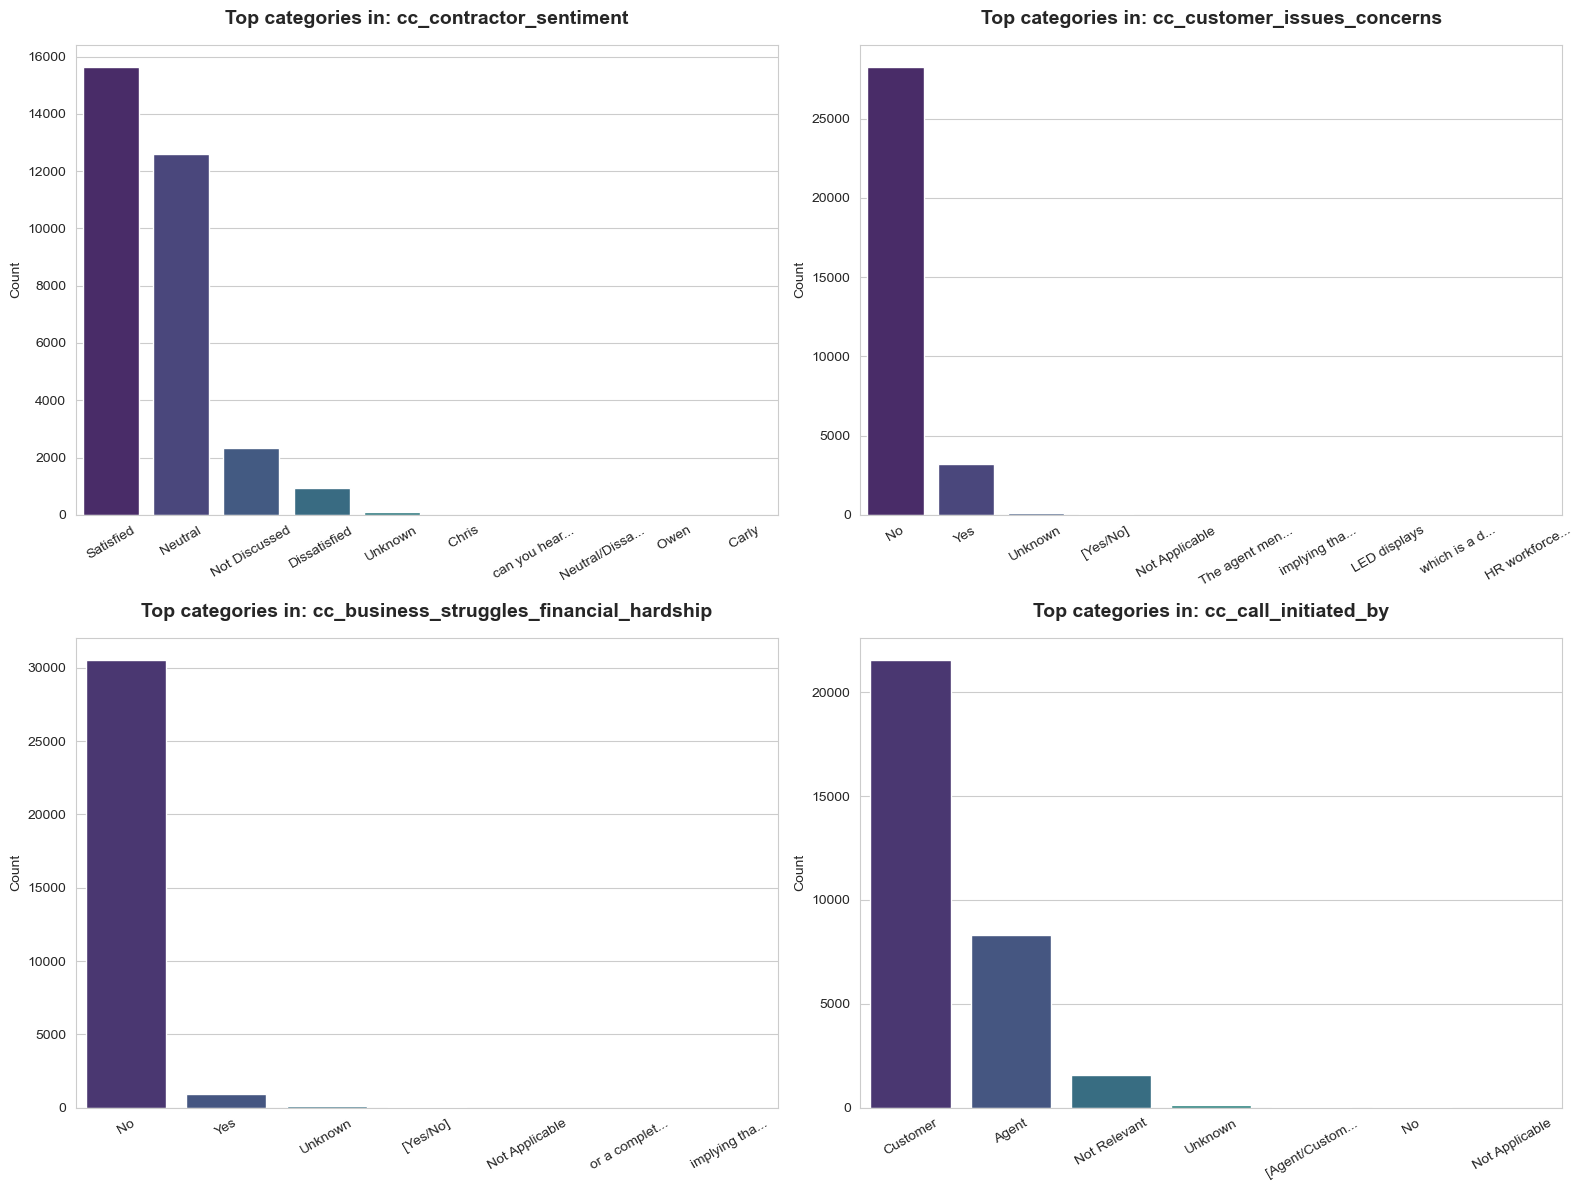

In [20]:

cat_imp_cols = [
    'cc_contractor_sentiment',
    'cc_customer_issues_concerns',
    'cc_business_struggles_financial_hardship',
    'cc_call_initiated_by'
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_imp_cols):
    top_data = df[col].value_counts().head(10)
    
    small_labels = [
        (str(name)[:13] + "...") if len(str(name)) > 16 else name 
        for name in top_data.index
    ]
    
    sns.barplot(x=small_labels, y=top_data.values, ax=axes[i], palette="viridis")

    axes[i].set_title(f"Top categories in: {col}", fontsize=14, fontweight='bold', pad=15)
    axes[i].tick_params(axis='x', labelrotation=30)
        
    axes[i].set_ylabel("Count")
    axes[i].set_xlabel(None)

plt.tight_layout()
plt.show()

Categorical columns to numerical conversion

In [21]:
cat_to_num_cols = [
    'cc_contractor_sentiment_start_score',
    'cc_contractor_sentiment_end_score',
    'cc_contractor_sentiment_overall_score',
    'cc_contractor_sentiment_issues_score'
]

df[cat_to_num_cols] = df[cat_to_num_cols].apply(pd.to_numeric, errors='coerce')

print("Missing %: ")
for col in cat_to_num_cols:
    print(f'{col}: {(df[col].isnull().mean() * 100).round(2)}')

Missing %: 
cc_contractor_sentiment_start_score: 0.74
cc_contractor_sentiment_end_score: 0.74
cc_contractor_sentiment_overall_score: 15.16
cc_contractor_sentiment_issues_score: 66.22


In [22]:
df[cat_to_num_cols].corr()

,cc_contractor_sentiment_start_score,cc_contractor_sentiment_end_score,cc_contractor_sentiment_overall_score,cc_contractor_sentiment_issues_score
cc_contractor_sentiment_start_score,1.000000,0.339109,0.333184,0.501511
cc_contractor_sentiment_end_score,0.339109,1.000000,0.945925,0.827461
cc_contractor_sentiment_overall_score,0.333184,0.945925,1.000000,0.903979
cc_contractor_sentiment_issues_score,0.501511,0.827461,0.903979,1.000000


Dropping issues score as High correlation bw overall and issues score

In [23]:
df = df.drop('cc_contractor_sentiment_issues_score', axis=1)

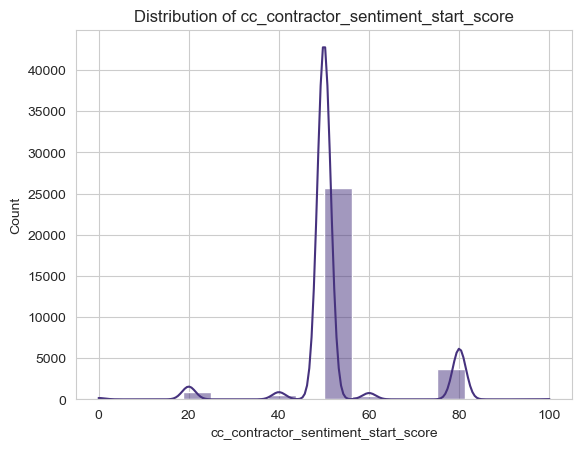

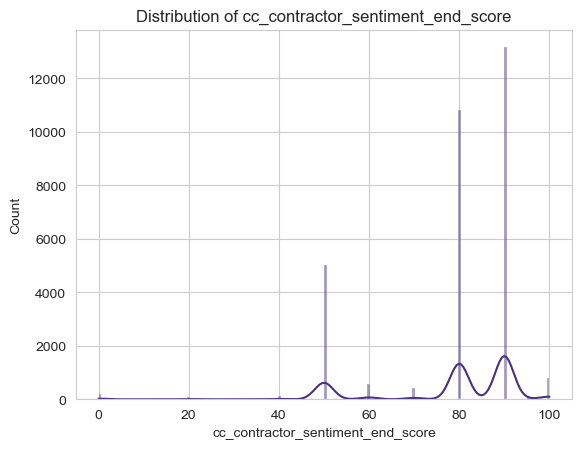

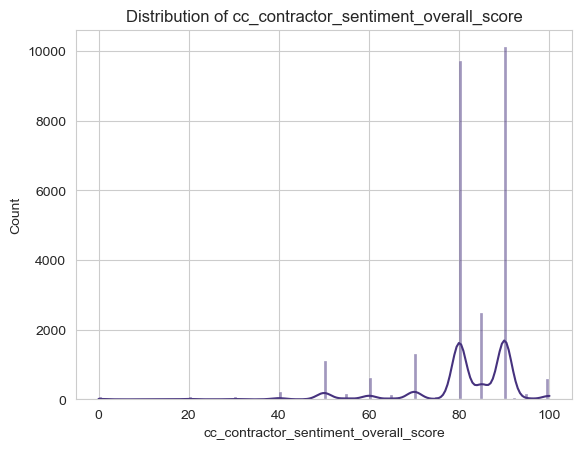

In [24]:
cat_to_num_cols = cat_to_num_cols[:3]

for col in cat_to_num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

Updating start/end/overall sentiment score null values with median

In [25]:
for col in cat_to_num_cols:
    median = df[col].median()
    df[col] = df[col].fillna(median)
    
df[cat_to_num_cols].isnull().values.any()

False

Updating cat_cols list after conversion

In [26]:
numerical_df = df.select_dtypes(include=['number'])
categorical_df = df.select_dtypes(include=['object', 'category'])

num_cols = numerical_df.columns.tolist()
cat_cols = categorical_df.columns.tolist()

print(f"Numerical: {num_cols}")
print(f"Categorical: {cat_cols}")

Numerical: ['contact_id', 'cc_contractor_sentiment_start_score', 'cc_contractor_sentiment_end_score', 'cc_contractor_sentiment_overall_score']
Categorical: ['direction', 'cc_care_package', 'cc_care_package_discussed', 'cc_urgency_getting_on_site', 'cc_external_consultant', 'cc_agent_cross_sell_attempt', 'cc_customer_issues_concerns', 'cc_business_struggles_financial_hardship', 'cc_call_initiated_by', 'cc_questionnaire_completion', 'cc_chasing_response', 'cc_issues_within_questionnaire', 'cc_login_issues', 'cc_platform_issues', 'cc_dissatisfaction_time_to_complete', 'cc_process_complexity_concerns', 'cc_questions_harder_than_expected', 'cc_dissatisfaction_support', 'cc_contractor_sentiment', 'cc_pricing_mentioned', 'cc_pricing_sentiment_impact', 'cc_refund_discussed', 'cc_contractor_suggest_leave', 'cc_contractor_complained', 'co_ref']


Cleaning & Standardizing Yes/No Categorical Features

In [27]:
yes_no_cols = []
valid_categories = {'Yes', 'No', 'Unknown'}

for col in cat_cols:
    unique_vals = df[col].unique()
    
    # Checking if unique vals is superset of valid categories
    if valid_categories.issubset(set(unique_vals)):
        yes_no_cols.append(col)
        
def clean_yes_no(col):
    return col.apply(lambda x: x if x in ['Yes', 'No'] else 'Unknown')

for col in yes_no_cols:
    df[col] = clean_yes_no(df[col])
    
df[yes_no_cols].apply(lambda s: s.value_counts()).T

,No,Yes,Unknown
cc_care_package_discussed,24668,6809,159
cc_urgency_getting_on_site,28285,3192,159
cc_external_consultant,28110,3367,159
cc_agent_cross_sell_attempt,30304,1153,179
cc_customer_issues_concerns,28248,3212,176
cc_business_struggles_financial_hardship,30530,939,167
cc_questionnaire_completion,25383,6210,43
cc_chasing_response,23847,7574,215
cc_issues_within_questionnaire,26213,4139,1284
cc_login_issues,29996,1587,53


Updating features where values has multiple categories

In [28]:
# Different Categorical values
multiple_categories_cols = ['cc_call_initiated_by', 'cc_care_package', 'cc_contractor_sentiment']

cc_care_package_categories = {'Not Discussed', 'Standard', 'Express', 'Premier', 'Unknown', 'Assisted'}
cc_call_initiated_by_categories = {'Customer', 'Agent', 'Unknown', 'Not Relevant'}
cc_contractor_sentiment_categories = {'Satisfied', 'Neutral', 'Not Discussed', 'Unknown', 'Dissatisfied'}

category_map = {
    'cc_care_package': cc_care_package_categories,
    'cc_call_initiated_by': cc_call_initiated_by_categories,
    'cc_contractor_sentiment': cc_contractor_sentiment_categories
}

for col, valid_set in category_map.items():
    df[col] = df[col].apply(lambda x: x if x in valid_set else 'Unknown')

Visualizing multiple categories features after cleaning and standardization

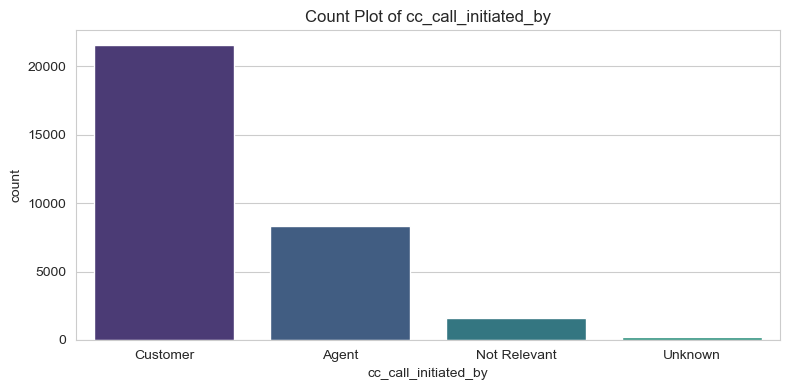

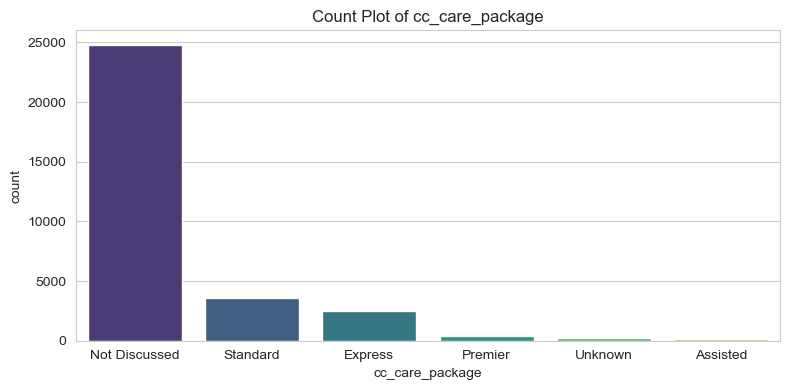

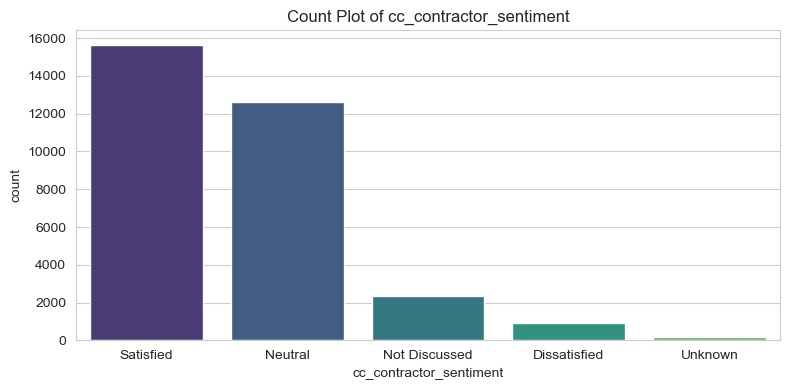

In [29]:
for col in multiple_categories_cols:
    plt.figure(figsize=(8, 4))
    
    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )
    
    plt.title(f"Count Plot of {col}")
    plt.tight_layout()
    plt.show()

Final Missing values check

In [30]:
print("If nulls exists in data: ", df.isnull().sum().any())
print(f"\nFinal shape: {df.shape}")

If nulls exists in data:  False

Final shape: (31636, 30)


##### Exporting excel file

In [31]:
df.to_csv('../../data/interim/cc_calls_cleaned.csv', index=False)